Import the required libraries

In [11]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
sns.set(style="whitegrid")

Load the dataset

In [12]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

# View first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Basic information

**SHAPE**

In [13]:
df.shape

(7043, 21)

**Column names**

In [14]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

**Data Types**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Summary Stastics**

In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Check for missing values**

In [17]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


As total charges is object data type but it has to be numeric converting them

In [18]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [19]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Fill the null values with median values

In [20]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_445/1479199042.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [21]:
df.duplicated().sum()

np.int64(0)

Churn exploration

In [22]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


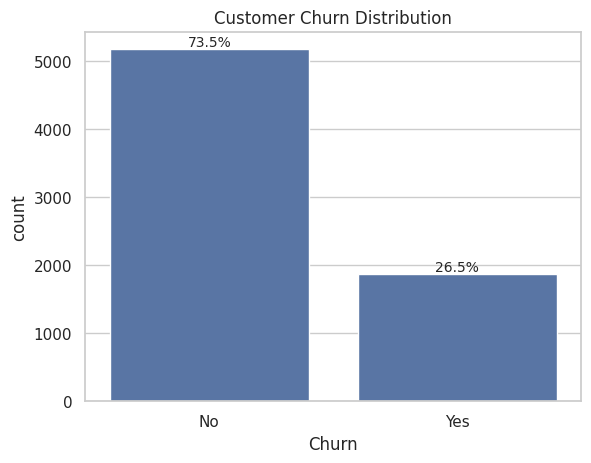

In [26]:
# Create the count plot
ax = sns.countplot(x="Churn", data=df)

# Calculate total number of observations
total = len(df)

# Add percentage labels
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=10)

plt.title("Customer Churn Distribution")
plt.show()

Explore numerical distributions

Tenure

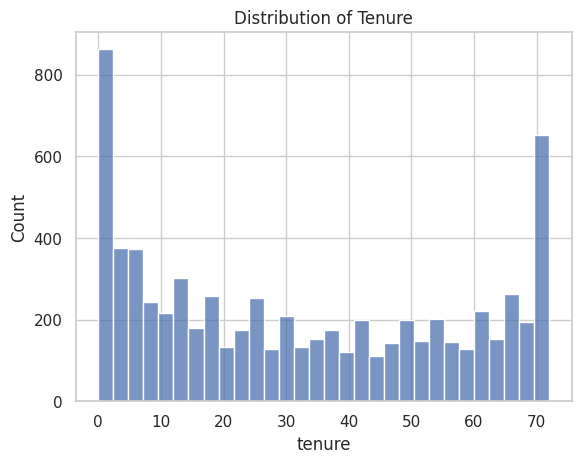

In [27]:
sns.histplot(df["tenure"], bins=30)
plt.title("Distribution of Tenure")
plt.show()

Monthly Charges

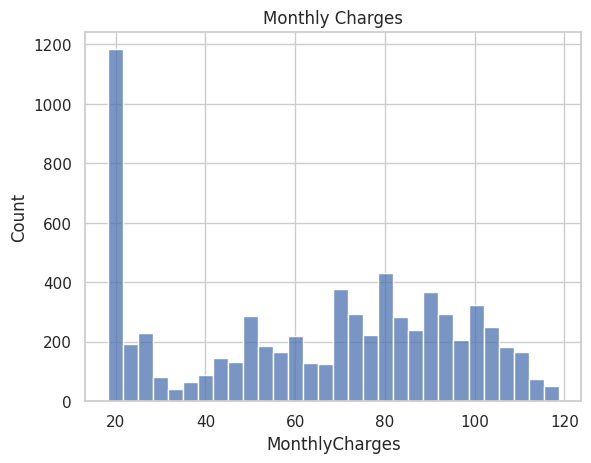

In [28]:
sns.histplot(df["MonthlyCharges"], bins=30)
plt.title("Monthly Charges")
plt.show()

Total Charges

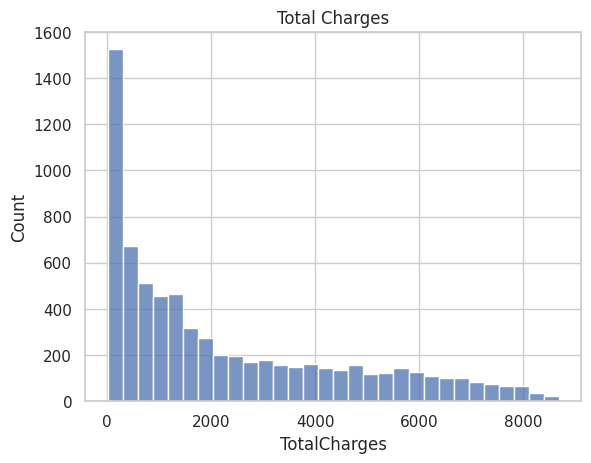

In [29]:
sns.histplot(df["TotalCharges"], bins=30)
plt.title("Total Charges")
plt.show()

Explore categorical variables

Gender

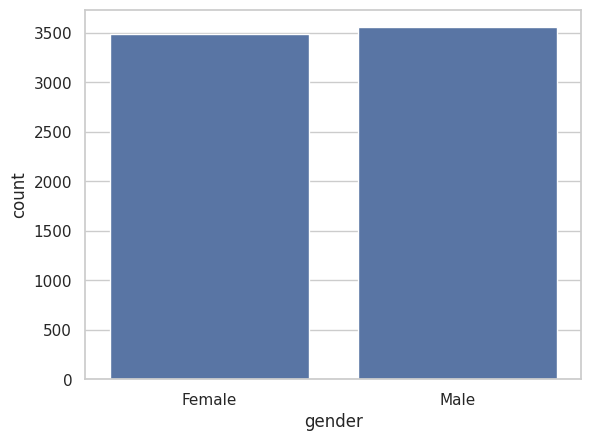

In [30]:
sns.countplot(x="gender", data=df)
plt.show()

Contract

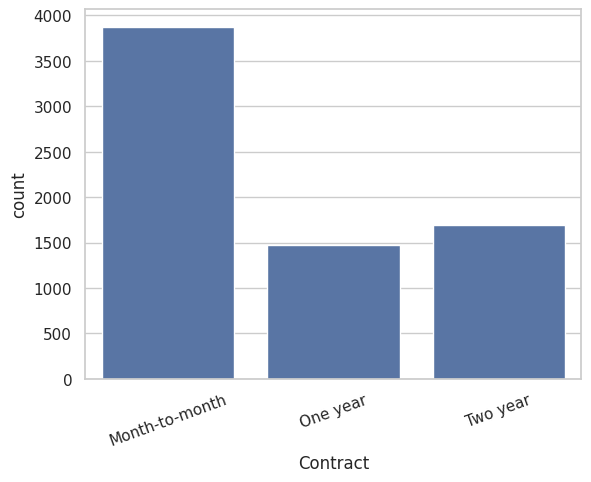

In [31]:
sns.countplot(x="Contract", data=df)
plt.xticks(rotation=20)
plt.show()

Internet Service

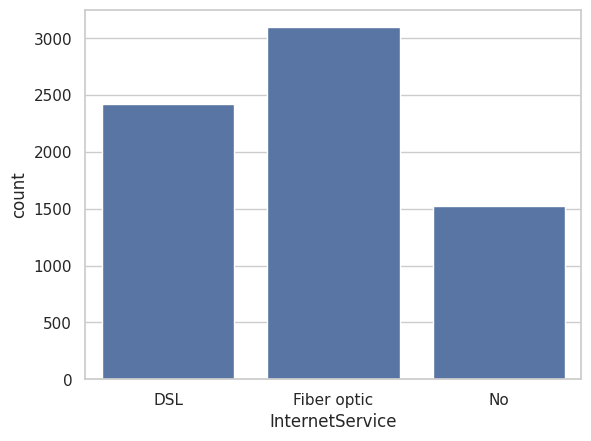

In [33]:
sns.countplot(x="InternetService", data=df)
plt.show()

Churn analysis

Churn By Gender

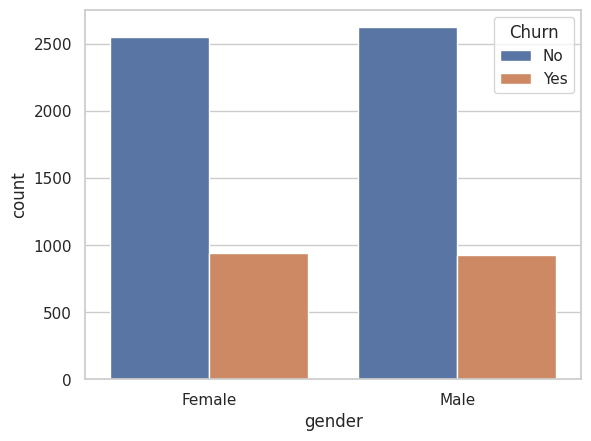

In [34]:
sns.countplot(x="gender", hue="Churn", data=df)
plt.show()

Churn By Contract

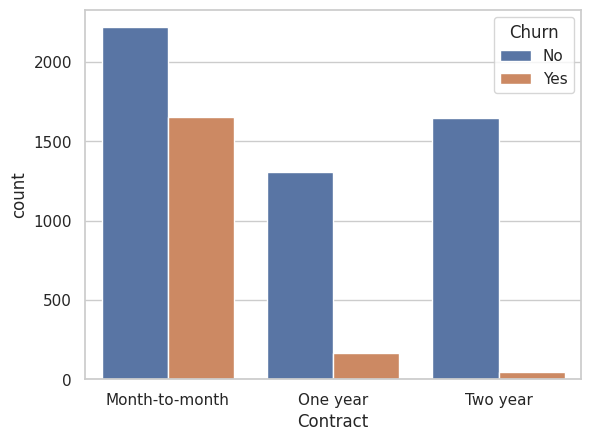

In [35]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

Churn By Payment Method

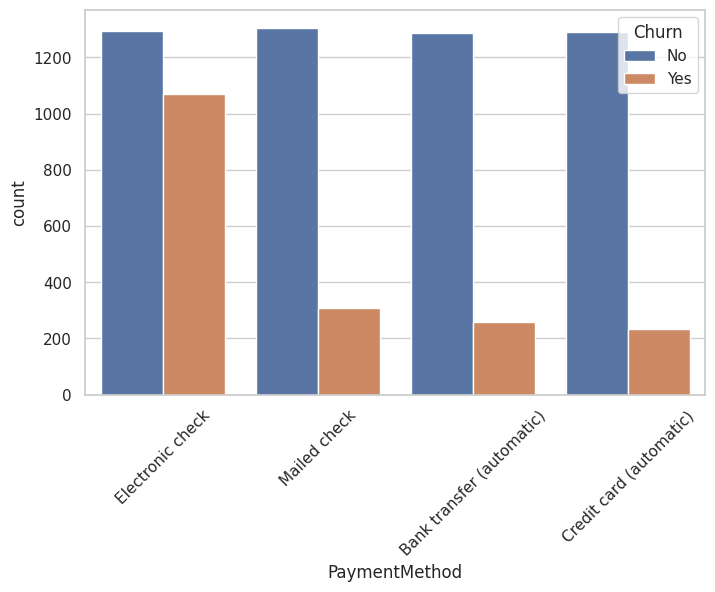

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.show()

Churn By Internet Service

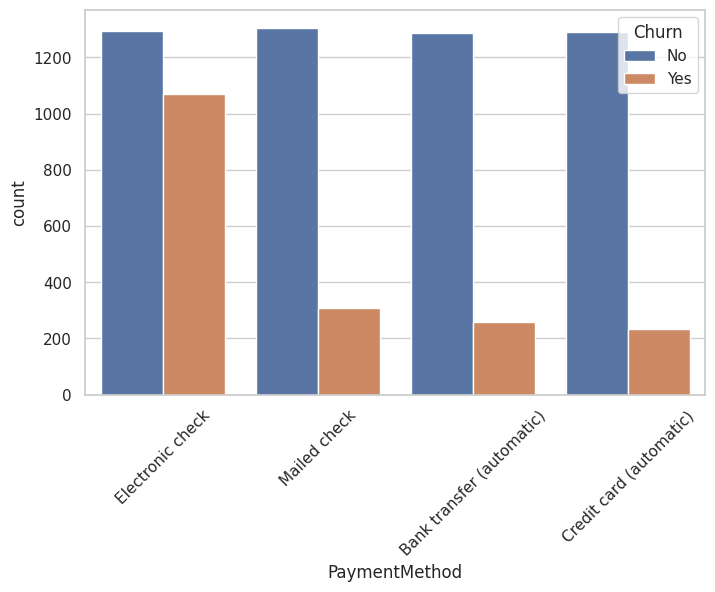

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)
plt.show()

Correlation between numerical feature

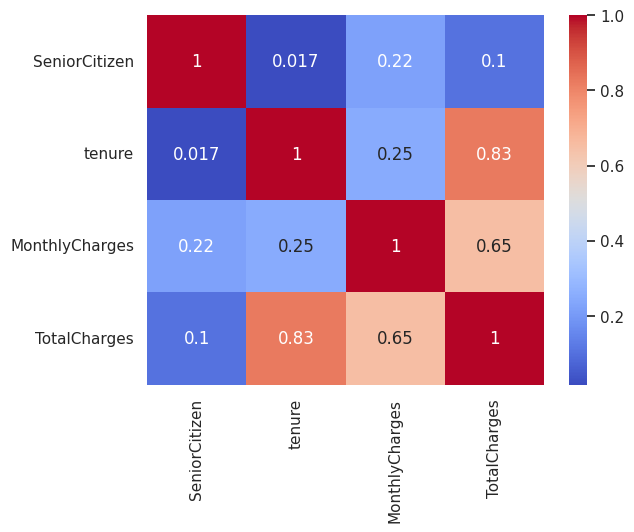

In [38]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Boxplots

Monthly Charges Vs Churn

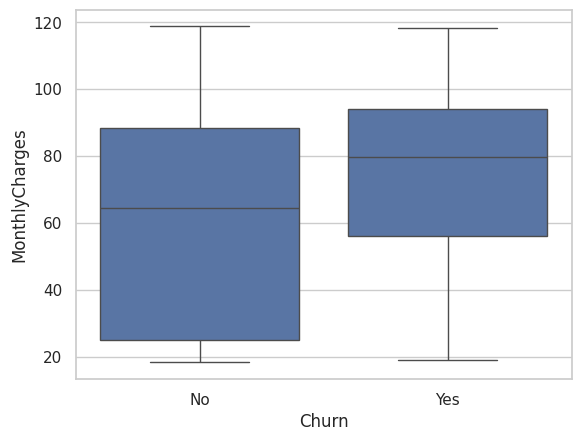

In [39]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.show()

Tenure Vs Churn

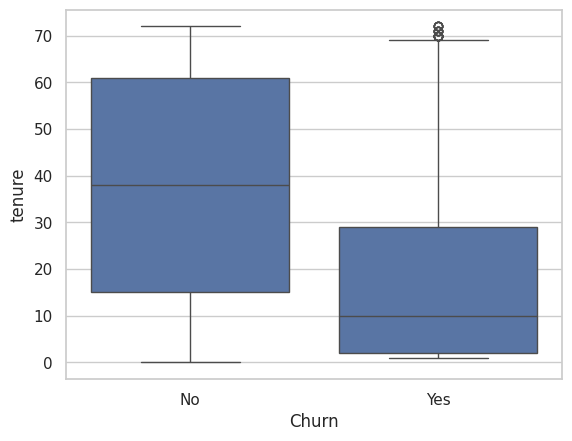

In [40]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.show()

In [41]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [42]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


Target Encoding: The Churn column was converted from categorical (Yes/No) to binary (1/0) so that it can be used directly by machine learning and causal inference models while preserving the same semantic meaning.

# Overall Conclusion

1. The `TotalCharges` column required preprocessing because it contained invalid blank values that were converted to `NaN` and handled appropriately.

2. After data cleaning, the dataset became more reliable for analysis by addressing missing values and removing duplicate records.

3. The customer churn distribution is imbalanced, with significantly more customers staying (`No`) than leaving (`Yes`).

4. Most customers prefer **month-to-month contracts**, making it the most common contract type in the dataset.

5. Customers with **month-to-month contracts show higher churn rates** compared to those with one-year or two-year contracts, suggesting that longer contracts improve customer retention.

6. The tenure distribution indicates a large number of both newly joined customers and long-term customers, while the middle tenure range has relatively fewer customers.

7. Lower monthly charges are more common among customers, and the distribution of total charges is concentrated at lower values before gradually decreasing.

8. `TotalCharges` has a strong positive relationship with both `MonthlyCharges` and `Tenure`, indicating that customers who stay longer or pay higher monthly fees accumulate higher total charges.

9. Gender does not appear to have a significant influence on churn, as the churn patterns for male and female customers are broadly similar.

10. Overall, **contract type, tenure, and billing-related features appear to be more influential in customer churn than demographic factors such as gender**, making them valuable predictors for churn analysis and future machine learning models.
